In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm.auto as tqdm
import numpy as np
from scipy.stats import pearsonr
import tqdm as t
from scipy import stats
from statsmodels.stats.multitest import multipletests

t.tqdm.pandas()

# Read prediction data

In [2]:
runs = [
    "kinodata_morgan_0_allsets",
    "kinodata_morgan_0_ic50_66f8",
    "kinodata_morgan_0_sets_5c05",
    "kinodata_morgan_1_allsets",
    "kinodata_morgan_1_ic50_5f6e",
    "kinodata_morgan_1_sets_b458",
    "kinodata_morgan_2_allsets",
    "kinodata_morgan_2_ic50_4523",
    "kinodata_morgan_2_sets_0392",
    "kinodata_morgan_3_allsets",
    "kinodata_morgan_3_ic50_47d5",
    "kinodata_morgan_3_sets_e67e",
    "kinodata_morgan_4_allsets",
    "kinodata_morgan_4_ic50_5e6b",
    "kinodata_morgan_4_sets_9751",
    "landrum_morgan_0_allsets",
    "landrum_morgan_0_ic50_402f",
    "landrum_morgan_0_sets_6fb1",
    "landrum_morgan_1_allsets",
    "landrum_morgan_1_ic50_4643",
    "landrum_morgan_1_sets_9ef8",
    "landrum_morgan_2_allsets",
    "landrum_morgan_2_ic50_0bde",
    "landrum_morgan_2_sets_0651",
    "landrum_morgan_3_allsets",
    "landrum_morgan_3_ic50_db6b",
    "landrum_morgan_3_sets_04c3",
    "landrum_morgan_4_allsets",
    "landrum_morgan_4_ic50_af10",
    "landrum_morgan_4_sets_7497",
    "omnivore_morgan_0_allsets",
    "omnivore_morgan_0_ic50_d9d1",
    "omnivore_morgan_0_sets_1e02",
    "omnivore_morgan_1_allsets",
    "omnivore_morgan_1_ic50_ce7d",
    "omnivore_morgan_1_sets_c799",
    "omnivore_morgan_2_allsets",
    "omnivore_morgan_2_ic50_5bb3",
    "omnivore_morgan_2_sets_481a",
    "omnivore_morgan_3_allsets",
    "omnivore_morgan_3_ic50_ab79",
    "omnivore_morgan_3_sets_c87c",
    "omnivore_morgan_4_allsets",
    "omnivore_morgan_4_ic50_f970",
    "omnivore_morgan_4_sets_334c",
]

In [3]:
all_preds = []
for run in tqdm.tqdm(runs):
    parts = run.split("_")
    dataset, fold, method = parts[0], parts[2], parts[3]
    df = pd.read_csv(f"../data/hpc-data/{run}/predictions.csv")
    df["dataset"] = dataset
    df["fold"] = fold
    df["method"] = method
    all_preds.append(df)
df = pd.concat(all_preds)

  0%|          | 0/45 [00:00<?, ?it/s]

In [4]:
df

,prediction,label,compound_id,assay_id,dataset,fold,method
0,0.587685,0.272134,4798177,4707740,kinodata,0,allsets
1,2.454761,-0.045347,4753387,4707740,kinodata,0,allsets
2,3.038855,-0.137057,4778502,4707740,kinodata,0,allsets
3,-3.198608,-0.292987,4787536,4707740,kinodata,0,allsets
4,1.465682,-0.156471,4786701,4707740,kinodata,0,allsets
...,...,...,...,...,...,...,...
159904,6.183723,-0.100002,393995,440741,omnivore,4,sets
159905,10.111128,0.325748,393991,440741,omnivore,4,sets
159906,12.785738,-0.152287,2658,440741,omnivore,4,sets
159907,8.927466,-0.607915,393999,440741,omnivore,4,sets


# Correlations over the entire test set (IC50 only)

In [5]:
overall_corrs = (
    df[df["method"] == "ic50"]
    .groupby(["dataset", "fold"])
    .corr(numeric_only=True)
    .loc[:, :, "prediction"]["label"]
    .reset_index()
)
overall_corrs

,dataset,fold,label
0,kinodata,0,0.563112
1,kinodata,1,0.559091
2,kinodata,2,0.594952
3,kinodata,3,0.587849
4,kinodata,4,0.552159
5,landrum,0,0.509015
6,landrum,1,0.500748
7,landrum,2,0.499979
8,landrum,3,0.517433
9,landrum,4,0.512775


# Assay-Aggregate Correlations

In [6]:
overall = []
corrs = []
too_small = 0
label_var = 0
pred_var = 0
for (dataset, fold, method), d in tqdm.tqdm(df.groupby(["dataset", "fold", "method"])):
    sizes = []
    pearsons = []
    for assay_id, g in d.groupby("assay_id"):
        size = len(g)
        if size <= 2:
            too_small += 1
            continue
        if np.std(g["label"].values) < 1e-9:
            label_var += 1
            continue
        if np.std(g["prediction"].values) < 1e-9:
            pred_var += 1
            continue
        corr = pearsonr(g["label"].values, g["prediction"].values)[0]

        corrs.append(
            dict(
                dataset=dataset,
                fold=fold,
                method=method,
                assay_id=assay_id,
                size=size,
                pearson=corr,
            )
        )
        sizes.append(size)
        pearsons.append(corr)
    pearsons = np.clip(pearsons, -1.0 + 1e-6, 1.0 - 1e-6)

    z_values = np.arctanh(pearsons)

    weights = np.array(sizes) - 3
    weights = np.maximum(weights, 1)
    avg_z = np.average(z_values, weights=weights)

    mean_pearson = np.tanh(avg_z)

    overall.append(
        dict(dataset=dataset, fold=fold, method=method, pearson=mean_pearson)
    )
    # print(f"dataset={dataset} fold={fold} method={method} corr={mean_pearson:.4f}")
assay_corrs = pd.DataFrame(overall)
corrs = pd.DataFrame(corrs)

  0%|          | 0/45 [00:00<?, ?it/s]

In [7]:
too_small, label_var, pred_var

(0, 876, 351)

In [8]:
method_order = ["ic50", "allsets", "sets"]
method_labels = {
    "ic50": "pointwise prediction",
    "allsets": "ranking (trained on random sets)",
    "sets": "ranking (trained on assay sets)",
    "overall ic50": "overall ic50",
}
for d in [corrs, assay_corrs]:
    d["method"] = pd.Categorical(d["method"], categories=method_order, ordered=True)
    d["method_label"] = d["method"].map(method_labels)

In [10]:
assay_corrs

,dataset,fold,method,pearson,method_label
0,kinodata,0,allsets,0.402009,ranking (trained on random sets)
1,kinodata,0,ic50,0.375309,pointwise prediction
2,kinodata,0,sets,0.437026,ranking (trained on assay sets)
3,kinodata,1,allsets,0.442679,ranking (trained on random sets)
4,kinodata,1,ic50,0.426039,pointwise prediction
5,kinodata,1,sets,0.478593,ranking (trained on assay sets)
6,kinodata,2,allsets,0.364693,ranking (trained on random sets)
7,kinodata,2,ic50,0.364420,pointwise prediction
8,kinodata,2,sets,0.410366,ranking (trained on assay sets)
9,kinodata,3,allsets,0.374512,ranking (trained on random sets)


In [12]:
summary = assay_corrs.pivot(
    index=["dataset", "fold"], columns="method_label", values="pearson"
)
summary

method_label   pointwise prediction  ranking (trained on random sets)  \
dataset  fold                                                           
kinodata 0                 0.375309                          0.402009   
         1                 0.426039                          0.442679   
         2                 0.364420                          0.364693   
         3                 0.375278                          0.374512   
         4                 0.369384                          0.401928   
landrum  0                 0.348672                          0.372403   
         1                 0.365828                          0.390505   
         2                 0.358350                          0.384429   
         3                 0.374677                          0.388425   
         4                 0.367806                          0.381644   
omnivore 0                 0.449631                          0.461908   
         1                 0.439427                          0.446665   
         2                 0.440797                          0.459806   
         3                 0.445052                          0.457705   
         4                 0.442111                          0.449881   

method_label   ranking (trained on assay sets)  
dataset  fold                                   
kinodata 0                            0.437026  
         1                            0.478593  
         2                            0.410366  
         3                            0.425165  
         4                            0.424462  
landrum  0                            0.402242  
         1                            0.422933  
         2                            0.410491  
         3                            0.420414  
         4                            0.402942  
omnivore 0                            0.468333  
         1                            0.455915  
         2                            0.467846  
         3                            0.460385  
         4                            0.453477

In [13]:
print(summary.to_latex(float_format="%.4f"))

\begin{tabular}{llrrr}
\toprule
 & method_label & pointwise prediction & ranking (trained on random sets) & ranking (trained on assay sets) \\
dataset & fold &  &  &  \\
\midrule
\multirow[t]{5}{*}{kinodata} & 0 & 0.3753 & 0.4020 & 0.4370 \\
 & 1 & 0.4260 & 0.4427 & 0.4786 \\
 & 2 & 0.3644 & 0.3647 & 0.4104 \\
 & 3 & 0.3753 & 0.3745 & 0.4252 \\
 & 4 & 0.3694 & 0.4019 & 0.4245 \\
\cline{1-5}
\multirow[t]{5}{*}{landrum} & 0 & 0.3487 & 0.3724 & 0.4022 \\
 & 1 & 0.3658 & 0.3905 & 0.4229 \\
 & 2 & 0.3584 & 0.3844 & 0.4105 \\
 & 3 & 0.3747 & 0.3884 & 0.4204 \\
 & 4 & 0.3678 & 0.3816 & 0.4029 \\
\cline{1-5}
\multirow[t]{5}{*}{omnivore} & 0 & 0.4496 & 0.4619 & 0.4683 \\
 & 1 & 0.4394 & 0.4467 & 0.4559 \\
 & 2 & 0.4408 & 0.4598 & 0.4678 \\
 & 3 & 0.4451 & 0.4577 & 0.4604 \\
 & 4 & 0.4421 & 0.4499 & 0.4535 \\
\cline{1-5}
\bottomrule
\end{tabular}



In [14]:
df = assay_corrs
df["z"] = np.arctanh(df["pearson"])


def cohen_d_pooled(x1, x2):
    n1, n2 = len(x1), len(x2)
    v1, v2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (np.mean(x1) - np.mean(x2)) / pooled_std


comparisons = [
    ("ic50", "allsets", "IC50 < ranking (inter-assay)"),
    ("ic50", "sets", "IC50 < ranking (intra-assay)"),
    ("allsets", "sets", "ranking (inter-assay) < ranking (intra-assay)"),
]

results = []
for ds in df["dataset"].unique():
    ds_df = df[df["dataset"] == ds]
    for m1, m2, label in comparisons:
        v1 = ds_df[ds_df["method"] == m1].sort_values("fold")["z"].values
        v2 = ds_df[ds_df["method"] == m2].sort_values("fold")["z"].values

        t_stat, p_t_2sided = stats.ttest_rel(v1, v2)
        p_t_onesided = p_t_2sided / 2 if t_stat < 0 else 1 - (p_t_2sided / 2)

        w_stat, p_w_onesided = stats.wilcoxon(v1, v2, alternative="less")

        d = cohen_d_pooled(v1, v2)

        results.append(
            {
                "dataset": ds,
                "comparison": label,
                "p_t_raw": p_t_onesided,
                "p_w_raw": p_w_onesided,
                "d": d,
            }
        )

p_t_all = [r["p_t_raw"] for r in results]
p_w_all = [r["p_w_raw"] for r in results]

_, p_t_fdr, _, _ = multipletests(p_t_all, method="fdr_bh")
_, p_w_fdr, _, _ = multipletests(p_w_all, method="fdr_bh")

for i in range(len(results)):
    results[i]["t-test (FDR)"] = p_t_fdr[i]
    results[i]["Wilcoxon (FDR)"] = p_w_fdr[i]

res_df = pd.DataFrame(results)
cols = ["dataset", "comparison", "t-test (FDR)", "Wilcoxon (FDR)", "d"]
print(
    res_df[cols]
    .set_index(["dataset", "comparison"])
    .to_latex(index=True, float_format="%.4f")
)

\begin{tabular}{llrrr}
\toprule
 &  & t-test (FDR) & Wilcoxon (FDR) & d \\
dataset & comparison &  &  &  \\
\midrule
\multirow[t]{3}{*}{kinodata} & IC50 < ranking (inter-assay) & 0.0437 & 0.0938 & -0.5405 \\
 & IC50 < ranking (intra-assay) & 0.0002 & 0.0352 & -2.0456 \\
 & ranking (inter-assay) < ranking (intra-assay) & 0.0014 & 0.0352 & -1.3293 \\
\cline{1-5}
\multirow[t]{3}{*}{landrum} & IC50 < ranking (inter-assay) & 0.0015 & 0.0352 & -2.3755 \\
 & IC50 < ranking (intra-assay) & 0.0003 & 0.0352 & -4.9879 \\
 & ranking (inter-assay) < ranking (intra-assay) & 0.0003 & 0.0352 & -3.3427 \\
\cline{1-5}
\multirow[t]{3}{*}{omnivore} & IC50 < ranking (inter-assay) & 0.0034 & 0.0352 & -2.1519 \\
 & IC50 < ranking (intra-assay) & 0.0019 & 0.0352 & -3.1733 \\
 & ranking (inter-assay) < ranking (intra-assay) & 0.0050 & 0.0352 & -0.8986 \\
\cline{1-5}
\bottomrule
\end{tabular}



In [15]:
res_df[cols].set_index(["dataset", "comparison"])

t-test (FDR)  \
dataset  comparison                                                    
kinodata IC50 < ranking (inter-assay)                       0.043696   
         IC50 < ranking (intra-assay)                       0.000202   
         ranking (inter-assay) < ranking (intra-assay)      0.001381   
landrum  IC50 < ranking (inter-assay)                       0.001488   
         IC50 < ranking (intra-assay)                       0.000342   
         ranking (inter-assay) < ranking (intra-assay)      0.000342   
omnivore IC50 < ranking (inter-assay)                       0.003361   
         IC50 < ranking (intra-assay)                       0.001855   
         ranking (inter-assay) < ranking (intra-assay)      0.004963   

                                                        Wilcoxon (FDR)  \
dataset  comparison                                                      
kinodata IC50 < ranking (inter-assay)                         0.093750   
         IC50 < ranking (intra-assay)                         0.035156   
         ranking (inter-assay) < ranking (intra-assay)        0.035156   
landrum  IC50 < ranking (inter-assay)                         0.035156   
         IC50 < ranking (intra-assay)                         0.035156   
         ranking (inter-assay) < ranking (intra-assay)        0.035156   
omnivore IC50 < ranking (inter-assay)                         0.035156   
         IC50 < ranking (intra-assay)                         0.035156   
         ranking (inter-assay) < ranking (intra-assay)        0.035156   

                                                               d  
dataset  comparison                                               
kinodata IC50 < ranking (inter-assay)                  -0.540503  
         IC50 < ranking (intra-assay)                  -2.045631  
         ranking (inter-assay) < ranking (intra-assay) -1.329324  
landrum  IC50 < ranking (inter-assay)                  -2.375454  
         IC50 < ranking (intra-assay)                  -4.987913  
         ranking (inter-assay) < ranking (intra-assay) -3.342701  
omnivore IC50 < ranking (inter-assay)                  -2.151931  
         IC50 < ranking (intra-assay)                  -3.173313  
         ranking (inter-assay) < ranking (intra-assay) -0.898616

In [11]:
method_order = ["ic50", "allsets", "sets"]
method_labels = {
    "ic50": "pointwise prediction",
    "allsets": "ranking (trained on random sets)",
    "sets": "ranking (trained on assay sets)",
    "overall ic50": "overall ic50",
}
for d in [corrs, assay_corrs]:
    d["method"] = pd.Categorical(d["method"], categories=method_order, ordered=True)
    d["method_label"] = d["method"].map(method_labels)

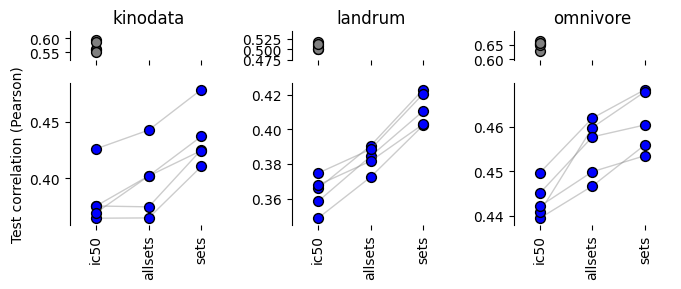

In [12]:
metric = "pearson"
fig, axes = plt.subplots(
    nrows=2, ncols=3, sharex=True, sharey=False, figsize=(7, 3), height_ratios=[1, 5]
)
plot_kws = dict(color="gray", alpha=0.4, linewidth=1, zorder=9)
scatter_kws = dict(zorder=9, s=50, marker="o", edgecolors="black", linewidths=1)
for ax, (dataset, subdf) in zip(axes[0], overall_corrs.groupby("dataset")):
    ax.set_title(dataset)
    corrs_total = subdf["label"].values
    ax.scatter(
        [0] * len(subdf), corrs_total, label="overall", color="gray", **scatter_kws
    )
    ax.set_ylim(corrs_total.min() * 0.95, corrs_total.max() * 1.05)
    ax.set_xticks([], [])
    sns.despine(ax=ax, bottom=True)
for ax, (dataset, subdf) in zip(axes[1], assay_corrs.groupby("dataset")):
    for fold, fold_df in subdf.groupby("fold"):
        fold_df = fold_df.sort_values("method")
        ax.plot(fold_df["method_label"], fold_df[metric], **plot_kws)
        ax.scatter(
            fold_df["method_label"],
            fold_df[metric],
            color="blue",
            label="per-set",
            **scatter_kws,
        )
        ax.set_xticks([0, 1, 2], method_order)  # ['a', 'b', 'c'])
        ax.tick_params("x", rotation=90)
        ax.set_xlim(-0.5, 2.5)
        # ax.set_ylim(0.35,.5)
        sns.despine(ax=ax, bottom=True)
axes[1][0].set_ylabel("Test correlation (Pearson)")
# plt.legend()
plt.tight_layout()
plt.savefig("results.pdf")

In [12]:
rows = []
for (dataset, method), d in corrs.groupby(["dataset", "method"]):
    print(dataset, method)
    for thres in tqdm.tqdm(range(d["size"].max())):
        subset = d[(d["size"] <= thres) & (~d["pearson"].isna())]
        aggcorr = np.tanh(
            (
                np.atanh(np.clip(subset["pearson"], -1 + 1e-10, 1 - 1e-10))
                * (subset["size"] - 3)
            ).sum()
            / (subset["size"] - 3).sum()
        )
        rows.append(
            dict(dataset=dataset, method=method, pearson=aggcorr, threshold=thres)
        )
bysize = pd.DataFrame(rows)

kinodata ic50


/tmp/ipykernel_8046/2311821230.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


  0%|          | 0/777 [00:00<?, ?it/s]

/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (


kinodata allsets


...

  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (


omnivore sets


  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/2311821230.py:7: RuntimeWarning: invalid value encountered in scalar divide
  (


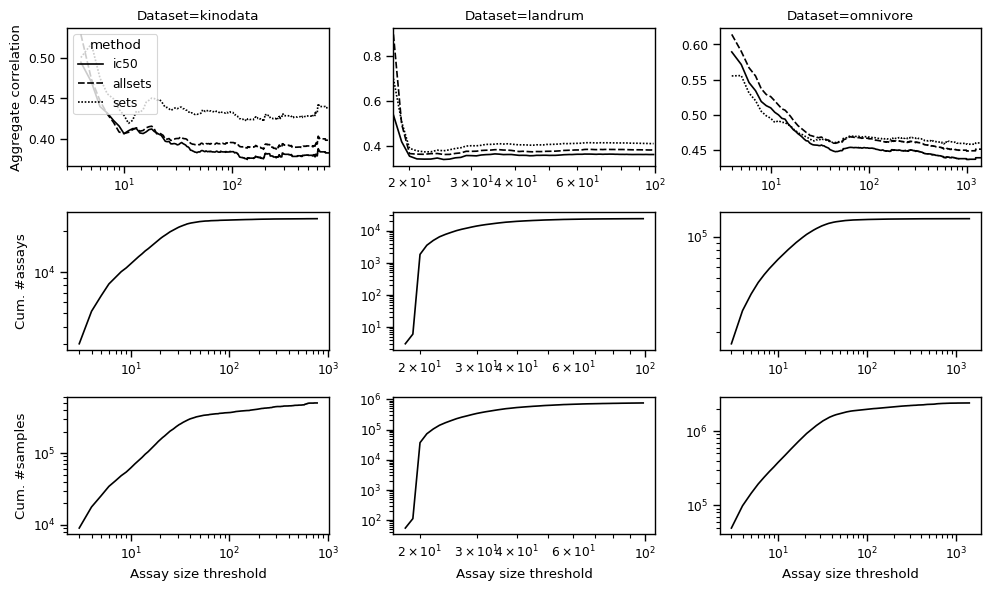

In [13]:
sns.set_context("paper")
fig, axes = plt.subplots(ncols=3, nrows=3, sharey=False, sharex=False, figsize=(10, 6))
for i, dataset in enumerate(["kinodata", "landrum", "omnivore"]):
    d = bysize[(bysize["dataset"] == dataset) & (bysize["threshold"] > 0)]
    ax = axes[0][i]
    sns.lineplot(
        d,
        style="method",
        # hue="dataset",
        y="pearson",
        x="threshold",
        ax=ax,
        legend=ax == axes[0][0],
        c="k",
    )
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_title(f"Dataset={dataset}")
    ax.set_xscale("log")
    ax = axes[1][i]
    d = corrs[corrs["dataset"] == dataset]
    sizes = list(range(d["size"].min(), d["size"].max()))
    ax.plot(sizes, [len(d[d["size"] <= threshold]) for threshold in sizes], c="k")
    ax.set_yscale("log")
    ax.set_xscale("log")
    axes[0][i].set_xlim(d["size"].min(), d["size"].max())
    ax = axes[2][i]
    ax.plot(
        sizes, [d[d["size"] <= threshold]["size"].sum() for threshold in sizes], c="k"
    )
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("Assay size threshold")

axes[0][0].set_ylabel("Aggregate correlation")
axes[1][0].set_ylabel("Cum. #assays")
axes[2][0].set_ylabel("Cum. #samples")
plt.tight_layout()
plt.savefig("performance_assaysize.pdf")

# Identify test sets with overlap

In [12]:
overlaps = []
for fold in tqdm.tqdm(range(5)):
    test = pd.read_csv(f"../data/processed/omnivore/{fold}/test.csv", index_col=0)
    train = pd.read_csv(f"../data/processed/omnivore/{fold}/train.csv", index_col=0)
    duplicates = test.merge(
        train[["compound_id", "assay_id", "target", "activity_value"]],
        on=["compound_id", "target", "activity_value"],
        how="inner",
    )
    overlaps.append(duplicates["assay_id_x"].unique())

  0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
overlaps = np.concat(overlaps)

In [14]:
import sqlite3
import pandas as pd

db_path = "/home/michael/Downloads/chembl_32/chembl_32_sqlite/chembl_32.db"

conn = sqlite3.connect(db_path)

In [15]:
assays_df = pd.read_sql_query("SELECT * FROM assays;", conn)

assays_df.head()

,assay_id,doc_id,description,assay_type,assay_test_type,assay_category,assay_organism,assay_tax_id,assay_strain,assay_tissue,...,confidence_score,curated_by,src_id,src_assay_id,chembl_id,cell_id,bao_format,tissue_id,variant_id,aidx
0,1,11087,The compound was tested for the in vitro inhib...,B,None,None,None,NaN,None,None,...,8,Autocuration,1,None,CHEMBL615117,NaN,BAO_0000019,NaN,NaN,CLD0
1,2,684,Compound was evaluated for its ability to mobi...,F,None,None,None,NaN,None,None,...,0,Autocuration,1,None,CHEMBL615118,NaN,BAO_0000219,NaN,NaN,CLD0
2,3,15453,None,B,None,None,None,NaN,None,None,...,0,Autocuration,1,None,CHEMBL615119,NaN,BAO_0000019,NaN,NaN,CLD0
3,4,17841,Binding affinity against A2 adenosine receptor...,B,None,None,Bos taurus,9913.0,None,Striatum,...,4,Autocuration,1,None,CHEMBL615120,NaN,BAO_0000249,2435.0,NaN,CLD0
4,5,17430,In vitro cell cytotoxicity against 143-B cell ...,F,None,None,Homo sapiens,9606.0,None,None,...,1,Intermediate,1,None,CHEMBL615121,163.0,BAO_0000219,NaN,NaN,CLD0


In [16]:
np.isnan(assays_df["doc_id"].unique()).any()

np.False_

In [17]:
corrs = corrs.merge(
    assays_df[["assay_id", "confidence_score"]], on="assay_id", how="left"
)

In [18]:
non_overlap_corrs = corrs[
    (corrs["dataset"] == "omnivore") & (~corrs["assay_id"].isin(overlaps))
]
overlap_corrs = corrs[
    (corrs["dataset"] == "omnivore") & (corrs["assay_id"].isin(overlaps))
]

In [19]:
def bysize(corrs):
    rows = []
    for (dataset, method), d in corrs.groupby(["dataset", "method"]):
        print(dataset, method)
        for thres in tqdm.tqdm(range(d["size"].max())):
            subset = d[(d["size"] <= thres) & (~d["pearson"].isna())]
            aggcorr = np.tanh(
                (
                    np.atanh(np.clip(subset["pearson"], -1 + 1e-10, 1 - 1e-10))
                    * (subset["size"] - 3)
                ).sum()
                / (subset["size"] - 3).sum()
            )
            rows.append(
                dict(dataset=dataset, method=method, pearson=aggcorr, threshold=thres)
            )
    return pd.DataFrame(rows)

## omnivore

In [20]:
bysize_non_overlap = bysize(non_overlap_corrs)
bysize_overlap = bysize(overlap_corrs)

omnivore ic50


/tmp/ipykernel_36831/154385903.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


  0%|          | 0/999 [00:00<?, ?it/s]

/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


omnivore allsets


...

  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


omnivore sets


  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


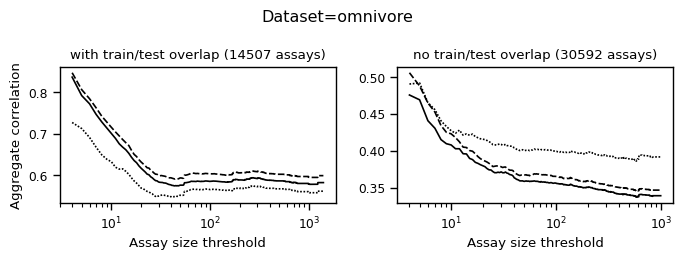

In [21]:
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 2.6)
)
sns.lineplot(
    bysize_overlap,
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize_non_overlap,
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=False,
    c="k",
)
ax1.set_xlabel("Assay size threshold")
ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()
plt.savefig("performance_assaysize_overlaps.pdf")

In [22]:
landrum = pd.read_csv("../data/raw/landrum.csv")

In [25]:
landrum_assays = landrum["assay_id"].unique()

In [28]:
non_overlap_corrs_bad = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "omnivore")
    & (~non_overlap_corrs["assay_id"].isin(overlaps))
    & (~non_overlap_corrs["assay_id"].isin(landrum_assays))
]
overlap_corrs_bad = overlap_corrs[
    (overlap_corrs["dataset"] == "omnivore")
    & (overlap_corrs["assay_id"].isin(overlaps))
    & (~overlap_corrs["assay_id"].isin(landrum_assays))
]
non_overlap_corrs_good = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "omnivore")
    & (~non_overlap_corrs["assay_id"].isin(overlaps))
    & (non_overlap_corrs["assay_id"].isin(landrum_assays))
]
overlap_corrs_good = overlap_corrs[
    (overlap_corrs["dataset"] == "omnivore")
    & (overlap_corrs["assay_id"].isin(overlaps))
    & (overlap_corrs["assay_id"].isin(landrum_assays))
]

In [29]:
len(non_overlap_corrs_bad), len(overlap_corrs_bad)

(77388, 34107)

omnivore ic50


/tmp/ipykernel_36831/154385903.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


  0%|          | 0/100 [00:00<?, ?it/s]

omnivore allsets


/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


...

  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


omnivore sets


  0%|          | 0/1407 [00:00<?, ?it/s]

/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_36831/154385903.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


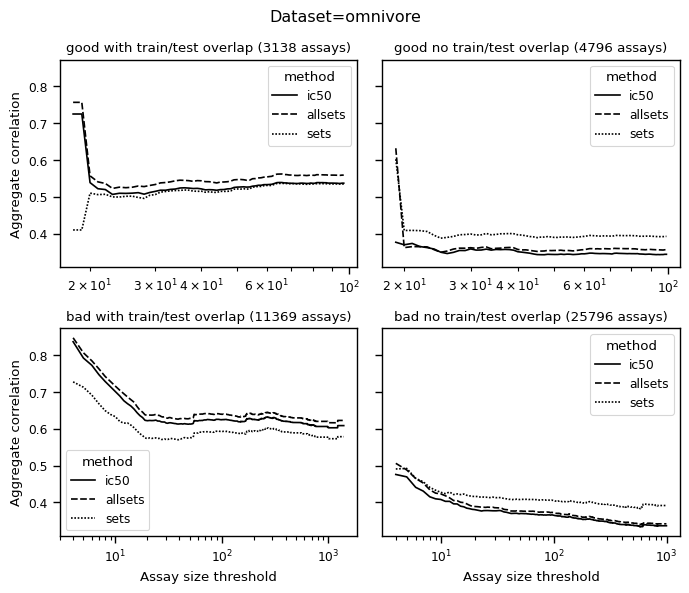

In [33]:
sns.set_context("paper")
fig, ((ax2, ax1), (ax4, ax3)) = plt.subplots(
    ncols=2, nrows=2, sharey=True, sharex=False, figsize=(7, 6)
)
sns.lineplot(
    bysize(non_overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=True,
    c="k",
)
# ax1.set_xlabel("Assay size threshold")
# ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")


sns.lineplot(
    bysize(non_overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax3,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax4,
    legend=True,
    c="k",
)
ax3.set_xlabel("Assay size threshold")
ax4.set_xlabel("Assay size threshold")
ax3.set_xscale("log")
ax4.set_xscale("log")

ax1.set_xlabel("")
ax2.set_xlabel("")
ax2.set_ylabel("Aggregate correlation")
ax1.set_ylabel("")
ax4.set_ylabel("Aggregate correlation")
ax3.set_ylabel("")
ax2.set_title(
    f"good with train/test overlap ({overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax1.set_title(
    f"good no train/test overlap ({non_overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax4.set_title(
    f"bad with train/test overlap ({overlap_corrs_bad['assay_id'].nunique()} assays)"
)
ax3.set_title(
    f"bad no train/test overlap ({non_overlap_corrs_bad['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()
plt.savefig("omnivore_bysize_goodbad_overlap.pdf")

In [107]:
df[df["dataset"] == "omnivore"]["assay_id"].nunique()

45453

## landrum

In [69]:
non_overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (~corrs["assay_id"].isin(overlaps))
]
overlap_corrs = corrs[
    (corrs["dataset"] == "landrum") & (corrs["assay_id"].isin(overlaps))
]

landrum ic50


/tmp/ipykernel_8046/3849932702.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


  0%|          | 0/98 [00:00<?, ?it/s]

landrum allsets


/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


...

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


landrum sets


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


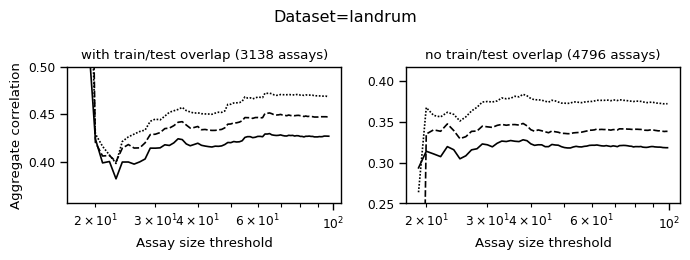

In [71]:
sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1, sharey=False, sharex=False, figsize=(7, 2.6)
)
sns.lineplot(
    bysize(overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=False,
    c="k",
)


sns.lineplot(
    bysize(non_overlap_corrs),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=False,
    c="k",
)
ax1.set_xlabel("Assay size threshold")
ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_ylim(0.25, None)
ax1.set_ylim(None, 0.5)

ax1.set_ylabel("Aggregate correlation")
ax2.set_ylabel("")
ax1.set_title(f"with train/test overlap ({overlap_corrs['assay_id'].nunique()} assays)")
ax2.set_title(
    f"no train/test overlap ({non_overlap_corrs['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=landrum")
plt.tight_layout()
plt.savefig("performance_assaysize_overlaps_landrum.pdf")

In [72]:
non_overlap_corrs_bad = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "landrum")
    & (~non_overlap_corrs["assay_id"].isin(overlaps))
    & (non_overlap_corrs["confidence_score"] < 9)
]
overlap_corrs_bad = overlap_corrs[
    (overlap_corrs["dataset"] == "landrum")
    & (overlap_corrs["assay_id"].isin(overlaps))
    & (overlap_corrs["confidence_score"] < 9)
]
non_overlap_corrs_good = non_overlap_corrs[
    (non_overlap_corrs["dataset"] == "landrum")
    & (~non_overlap_corrs["assay_id"].isin(overlaps))
    & (non_overlap_corrs["confidence_score"] == 9)
]
overlap_corrs_good = overlap_corrs[
    (overlap_corrs["dataset"] == "landrum")
    & (overlap_corrs["assay_id"].isin(overlaps))
    & (overlap_corrs["confidence_score"] == 9)
]

In [73]:
len(non_overlap_corrs_bad), len(overlap_corrs_bad)

(0, 0)

landrum ic50


/tmp/ipykernel_8046/3849932702.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


  0%|          | 0/100 [00:00<?, ?it/s]

landrum allsets


/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


...

/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


landrum sets


  0%|          | 0/98 [00:00<?, ?it/s]

/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (
/tmp/ipykernel_8046/3849932702.py:8: RuntimeWarning: invalid value encountered in scalar divide
  (


ValueError: Could not interpret value `threshold` for `x`. An entry with this name does not appear in `data`.

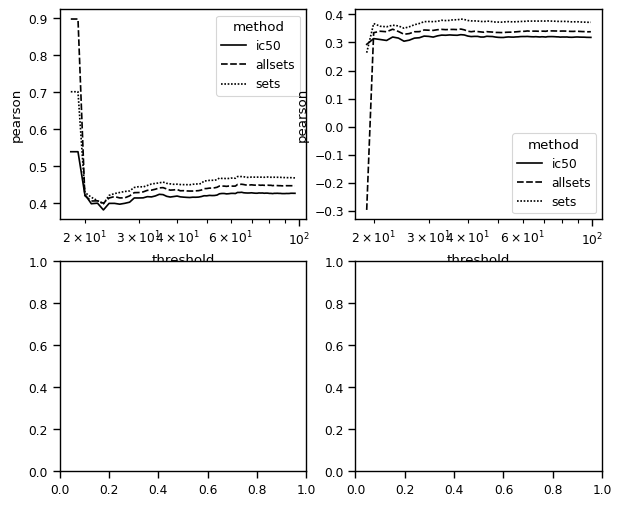

In [74]:
sns.set_context("paper")
fig, ((ax2, ax1), (ax4, ax3)) = plt.subplots(
    ncols=2, nrows=2, sharey=False, sharex=False, figsize=(7, 6)
)
sns.lineplot(
    bysize(non_overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax1,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_good),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax2,
    legend=True,
    c="k",
)
# ax1.set_xlabel("Assay size threshold")
# ax2.set_xlabel("Assay size threshold")
ax1.set_xscale("log")
ax2.set_xscale("log")


sns.lineplot(
    bysize(non_overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax3,
    legend=True,
    c="k",
)


sns.lineplot(
    bysize(overlap_corrs_bad),
    style="method",
    # hue="dataset",
    y="pearson",
    x="threshold",
    ax=ax4,
    legend=True,
    c="k",
)
ax3.set_xlabel("Assay size threshold")
ax4.set_xlabel("Assay size threshold")
ax3.set_xscale("log")
ax4.set_xscale("log")

ax2.set_ylabel("Aggregate correlation")
ax1.set_ylabel("")
ax4.set_ylabel("Aggregate correlation")
ax3.set_ylabel("")
ax2.set_title(
    f"good with train/test overlap ({overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax1.set_title(
    f"good no train/test overlap ({non_overlap_corrs_good['assay_id'].nunique()} assays)"
)
ax4.set_title(
    f"bad with train/test overlap ({overlap_corrs_bad['assay_id'].nunique()} assays)"
)
ax3.set_title(
    f"bad no train/test overlap ({non_overlap_corrs_bad['assay_id'].nunique()} assays)"
)
fig.suptitle("Dataset=omnivore")
plt.tight_layout()

In [68]:
non_overlap_corrs["overlapping compounds"] = False
overlap_corrs["overlapping compounds"] = True
corrs_overlap = pd.concat([non_overlap_corrs, overlap_corrs])

/tmp/ipykernel_64940/2590454731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_overlap_corrs['overlapping compounds'] = False
/tmp/ipykernel_64940/2590454731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  overlap_corrs['overlapping compounds'] = True


In [108]:
corrs_overlap

,dataset,fold,method,assay_id,size,pearson,method_label,overlapping compounds
48450,omnivore,0,allsets,26,7,0.917759,ranking (trained on random sets),False
48452,omnivore,0,allsets,165,27,-0.045640,ranking (trained on random sets),False
48453,omnivore,0,allsets,209,9,0.565627,ranking (trained on random sets),False
48454,omnivore,0,allsets,365,5,-0.732381,ranking (trained on random sets),False
48455,omnivore,0,allsets,458,28,0.489791,ranking (trained on random sets),False
...,...,...,...,...,...,...,...,...
183723,omnivore,4,sets,2165848,3,-0.015309,ranking (trained on assay sets),True
183733,omnivore,4,sets,2169612,13,0.940222,ranking (trained on assay sets),True
183738,omnivore,4,sets,2171316,21,0.309848,ranking (trained on assay sets),True
183739,omnivore,4,sets,2171607,4,-0.555342,ranking (trained on assay sets),True


<Axes: xlabel='size', ylabel='Density'>

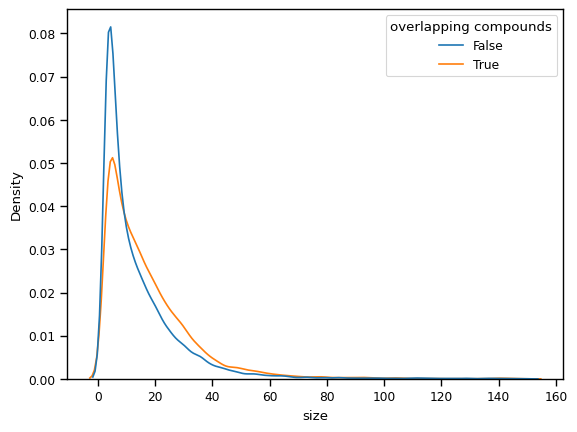

In [87]:
sns.kdeplot(
    corrs_overlap[corrs_overlap["size"] < 150],
    x="size",
    hue="overlapping compounds",
    common_norm=False,
)

In [99]:
(
    np.tanh((np.atanh(0.6) * 5 + np.atanh(0.1) * 5) / (2 * 5)),
    np.tanh((np.atanh(0.5) * 5 + np.atanh(0.1) * 5) / (2 * 5)),
)

(np.float64(0.3771572147352915), np.float64(0.3138593383654928))

In [101]:
(
    np.tanh((np.atanh(0.6) * 5 + np.atanh(0.1) * 5) / (2 * 5)),
    np.tanh((np.atanh(0.6) * 5 + np.atanh(0.2) * 5) / (2 * 5)),
)

(np.float64(0.3771572147352915), np.float64(0.42020410288672877))

In [102]:
n = 100
(
    np.tanh((np.atanh(0.6) * n + np.atanh(0.1) * n) / (2 * n)),
    np.tanh((np.atanh(0.6) * n + np.atanh(0.2) * n) / (2 * n)),
)

(np.float64(0.3771572147352915), np.float64(0.42020410288672877))

<Axes: xlabel='size', ylabel='Count'>

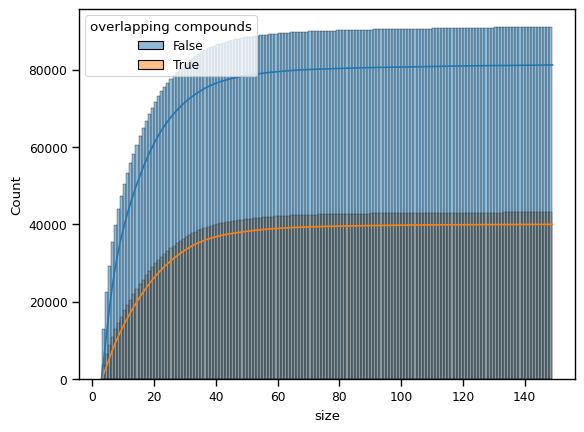

In [84]:
sns.histplot(
    corrs_overlap[corrs_overlap["size"] < 150],
    x="size",
    hue="overlapping compounds",
    multiple="layer",
    binwidth=1,
    cumulative=True,
    kde=True,
)
# plt.yscale('log')

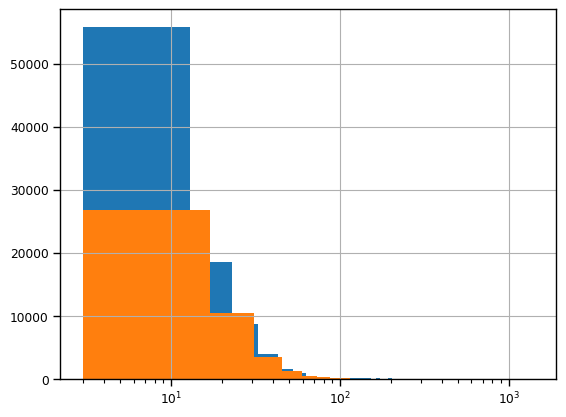

In [63]:
non_overlap_corrs["size"].hist(bins=100)
overlap_corrs["size"].hist(bins=100)
plt.xscale("log")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def fisher_aggregate(subset):
    """Computes Fisher Z-transformed weighted average correlation."""
    # Fisher transform: z = atanh(r)
    # Weights: w = size - 3 (standard for Pearson variance)
    z = np.arctanh(np.clip(subset["pearson"], -1 + 1e-10, 1 - 1e-10))
    weights = subset["size"] - 3
    mask = (weights > 0) & (~z.isna())

    if not mask.any():
        return np.nan

    weighted_z = (z[mask] * weights[mask]).sum() / weights[mask].sum()
    return np.tanh(weighted_z)

In [28]:
for (dataset, method), d in corrs.groupby(["dataset", "method"]):
    d = d.copy()
    # Create the bins
    d["q_bin"], bins = pd.qcut(
        d["size"], q=num_quantiles, retbins=True, duplicates="drop"
    )

    for i, bin_interval in enumerate(d["q_bin"].cat.categories):
        subset = d[d["q_bin"] == bin_interval]

        # Calculate weighted average
        z = np.arctanh(np.clip(subset["pearson"], -1 + 1e-10, 1 - 1e-10))
        weights = subset["size"] - 3
        mask = (weights > 0) & (~z.isna())

        if mask.any():
            aggcorr = np.tanh((z[mask] * weights[mask]).sum() / weights[mask].sum())
        else:
            aggcorr = np.nan

        # Create a clean label for the range: e.g., "12-45"
        label = f"{int(bin_interval.left)}-{int(bin_interval.right)}"

        rows.append(
            {
                "dataset": dataset,
                "method": method,
                "pearson": aggcorr,
                "bin_label": label,
                "bin_index": i,
            }
        )

bysize_q = pd.DataFrame(rows)

/tmp/ipykernel_99220/2389659007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (dataset, method), d in corrs.groupby(["dataset", "method"]):


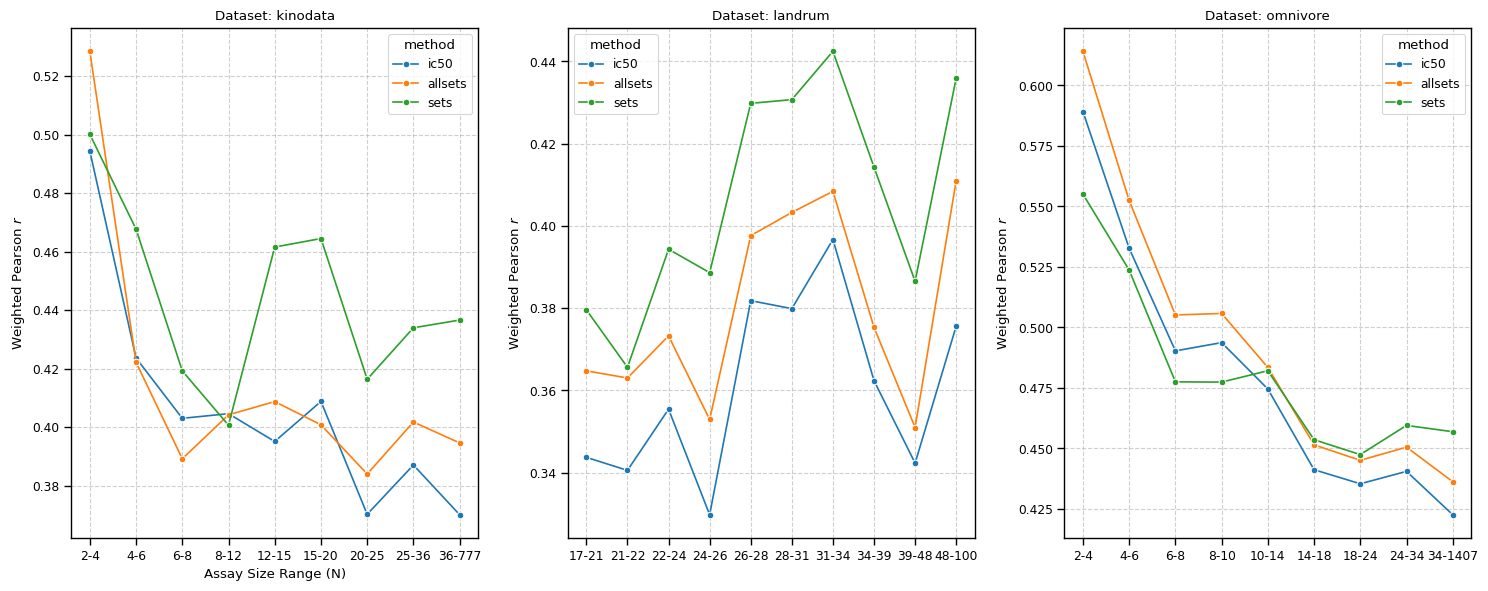

In [33]:
sns.set_context("paper")
datasets = bysize_q["dataset"].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(15, 6), sharey=False)

for i, dataset in enumerate(datasets):
    ax = axes[i]
    d_plot = bysize_q[bysize_q["dataset"] == dataset]

    sns.lineplot(
        data=d_plot,
        x="bin_label",  # The size ranges are now the Y-ticks
        y="pearson",
        hue="method",
        marker="o",
        ax=ax,
        sort=False,  # Keep the quantile order
    )

    ax.set_title(f"Dataset: {dataset}")
    ax.set_ylabel("Weighted Pearson $r$")
    ax.set_xlabel("Assay Size Range (N)" if i == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("quantile_performance.pdf")

In [26]:
bysize_q

,dataset,method,pearson,threshold,quantile
0,kinodata,ic50,0.494411,4,0
1,kinodata,ic50,0.423621,6,1
2,kinodata,ic50,0.403004,8,2
3,kinodata,ic50,0.404594,12,3
4,kinodata,ic50,0.395091,15,4
...,...,...,...,...,...
79,omnivore,sets,0.482091,14,4
80,omnivore,sets,0.453595,18,5
81,omnivore,sets,0.447445,24,6
82,omnivore,sets,0.459517,34,7


<Axes: xlabel='prediction', ylabel='label'>

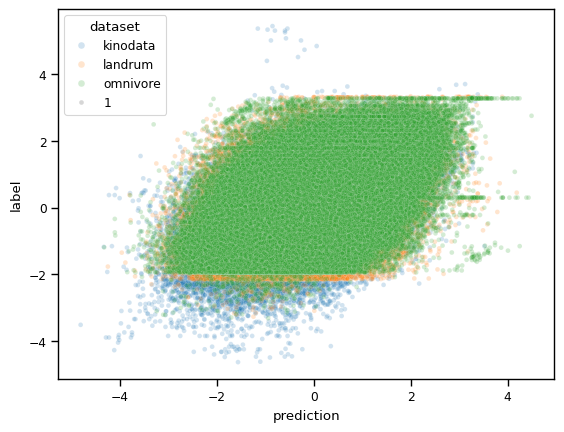

In [36]:
sns.scatterplot(
    data=df[df["method"] == "ic50"],
    x="prediction",
    y="label",
    hue="dataset",
    size=1,
    alpha=0.2,
)